In [22]:
#Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#Step 2: Load Dataset
df = pd.read_csv('/content/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [24]:
#Step 3: Check Dataset Information


df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [25]:
#Step 4: Remove Extra Column (If Present)

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [26]:
#Step 5: Statistical Summary

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


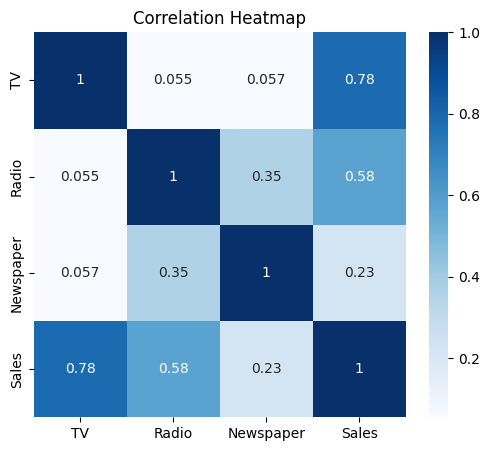

In [27]:
#Step 6: Correlation Heatmap

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

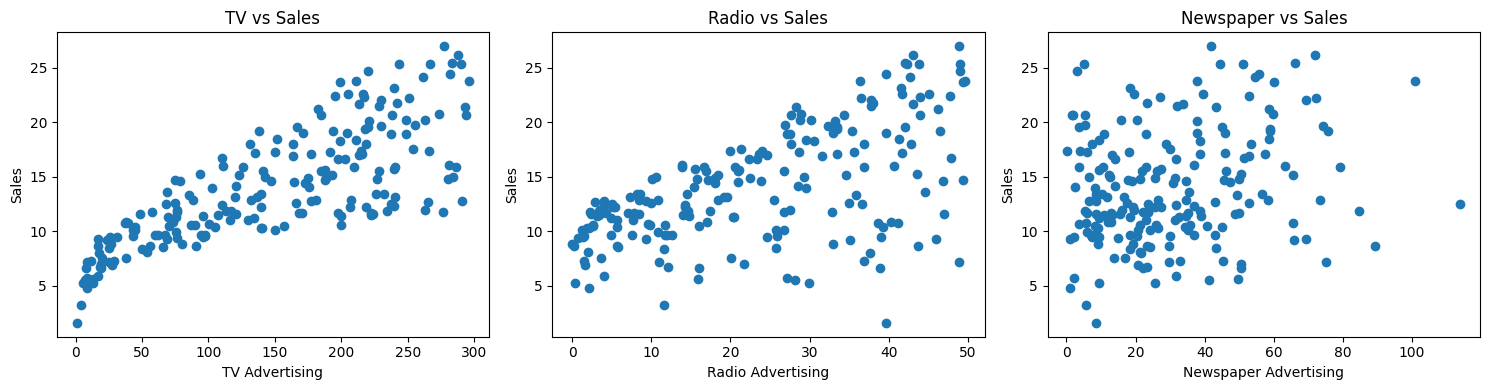

In [28]:
#Step 7: Visualize Advertising vs Sales


plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV vs Sales")

plt.subplot(1,3,2)
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio vs Sales")

plt.subplot(1,3,3)
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

In [29]:
#Step 8: Select Features and Target


X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [30]:
#Step 9: Split Data (Train/Test)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
#Step 10: Train Model

#We use Linear Regression.

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
#Step 11: Predict Sales

y_pred = model.predict(X_test)

print(y_pred[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [33]:
#Step 12: Evaluate Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.4607567168117603
MSE: 3.1740973539761033
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


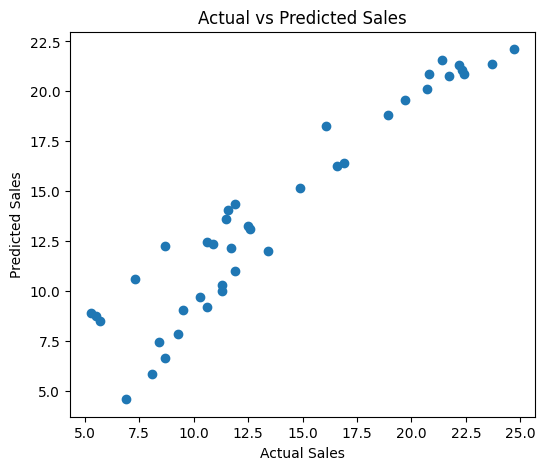

In [34]:
#Step 13: Actual vs Predicted Graph

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [35]:
#Step 14: Analyze Advertising Impact

importance = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
})

print(importance)

     Feature    Impact
0         TV  0.044730
1      Radio  0.189195
2  Newspaper  0.002761


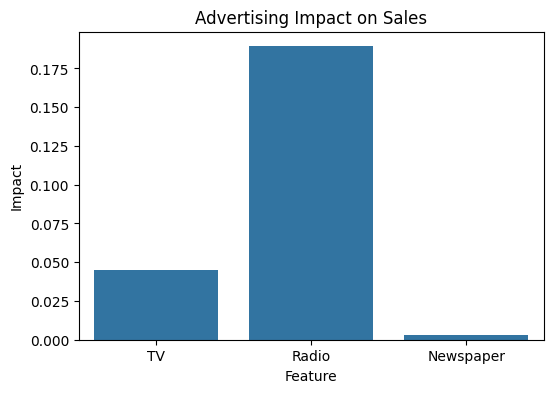

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(x='Feature', y='Impact', data=importance)

plt.title("Advertising Impact on Sales")
plt.show()

In [37]:
#Step 15: Predict Future Sales

new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [50]
})

future_sales = model.predict(new_data)

print("Predicted Sales:", future_sales[0])

Predicted Sales: 19.630828718309314


In [38]:
#Report:
"""
TV advertising has highest impact on sales.
Radio advertising moderately affects sales.
Newspaper advertising has less effect.
Increasing ad budget improves sales prediction.
Businesses should invest more in effective advertising channels.
"""

'\nTV advertising has highest impact on sales.\nRadio advertising moderately affects sales.\nNewspaper advertising has less effect.\nIncreasing ad budget improves sales prediction.\nBusinesses should invest more in effective advertising channels.\n'